# Model_experiments
---
Ahora toca probar el modelo que capta la tendencia con un modelo lineal y luego capturaremos la estacionalidad y lo ciclico con un modelo XGBoost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [7]:
families = ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD_BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS',
       'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']

dataframes = {}

for family in families:
    print(family)
    df_train = pd.read_csv(f'../data/processed/LinearandXGBoost/Linear/train/{family}_train.csv', parse_dates=['date'], index_col='date')
    df_test = pd.read_csv(f'../data/processed/LinearandXGBoost/Linear/test/{family}_test.csv', parse_dates=['date'], index_col='date')
    dataframes[family] = (df_train, df_test)


AUTOMOTIVE
BABY CARE
BEAUTY
BEVERAGES
BOOKS
BREAD_BAKERY
CELEBRATION
CLEANING
DAIRY
DELI
EGGS
FROZEN FOODS
GROCERY I
GROCERY II
HARDWARE
HOME AND KITCHEN I
HOME AND KITCHEN II
HOME APPLIANCES
HOME CARE
LADIESWEAR
LAWN AND GARDEN
LINGERIE
LIQUOR,WINE,BEER
MAGAZINES
MEATS
PERSONAL CARE
PET SUPPLIES
PLAYERS AND ELECTRONICS
POULTRY
PREPARED FOODS
PRODUCE
SCHOOL AND OFFICE SUPPLIES
SEAFOOD


In [8]:
models = {}

for family, (train_df, test_df) in dataframes.items():
    # Entrenamos el modelo de regresión lineal
    model = LinearRegression()
    model.fit(train_df[['days_since_start']], train_df['sales'])
    
    # Guardamos el modelo entrenado en el diccionario
    models[family] = model

AUTOMOTIVE


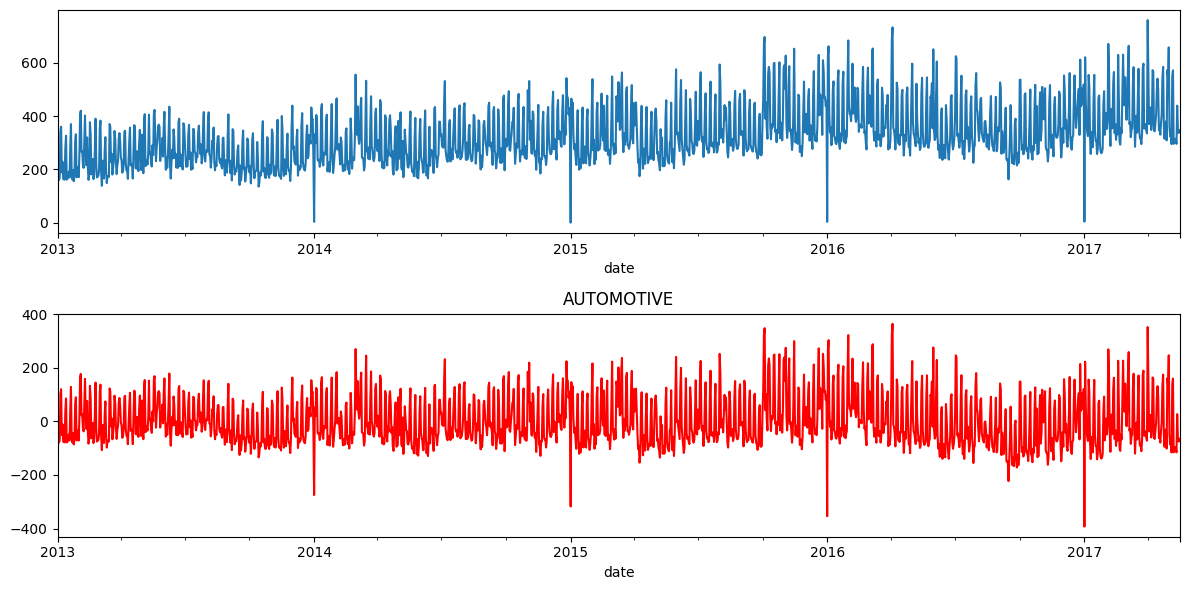

BABY CARE


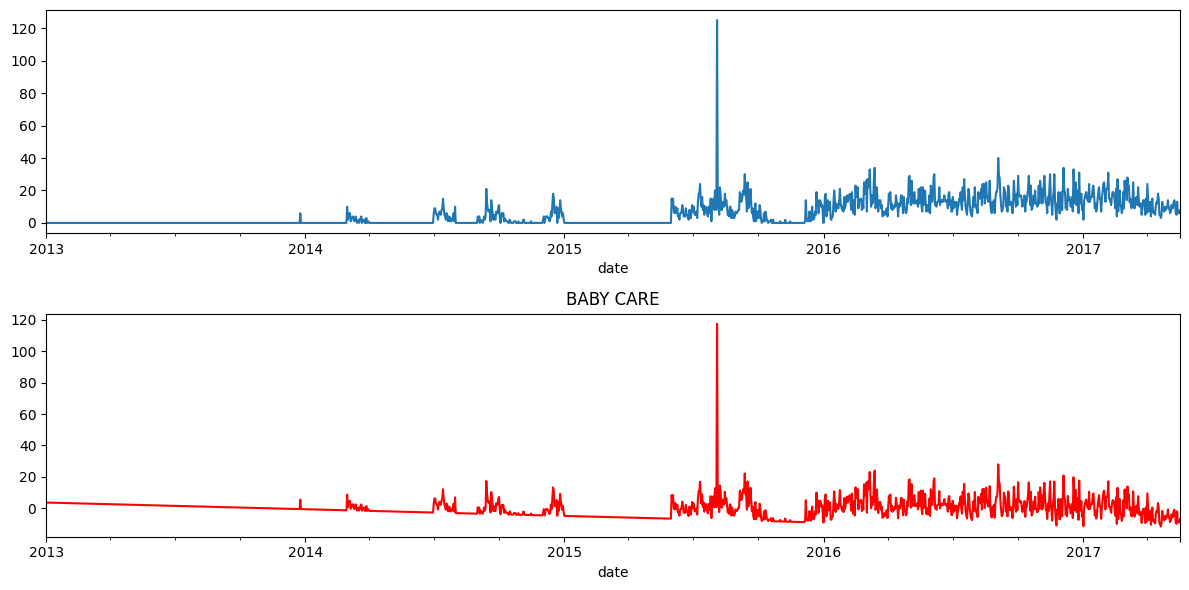

BEAUTY


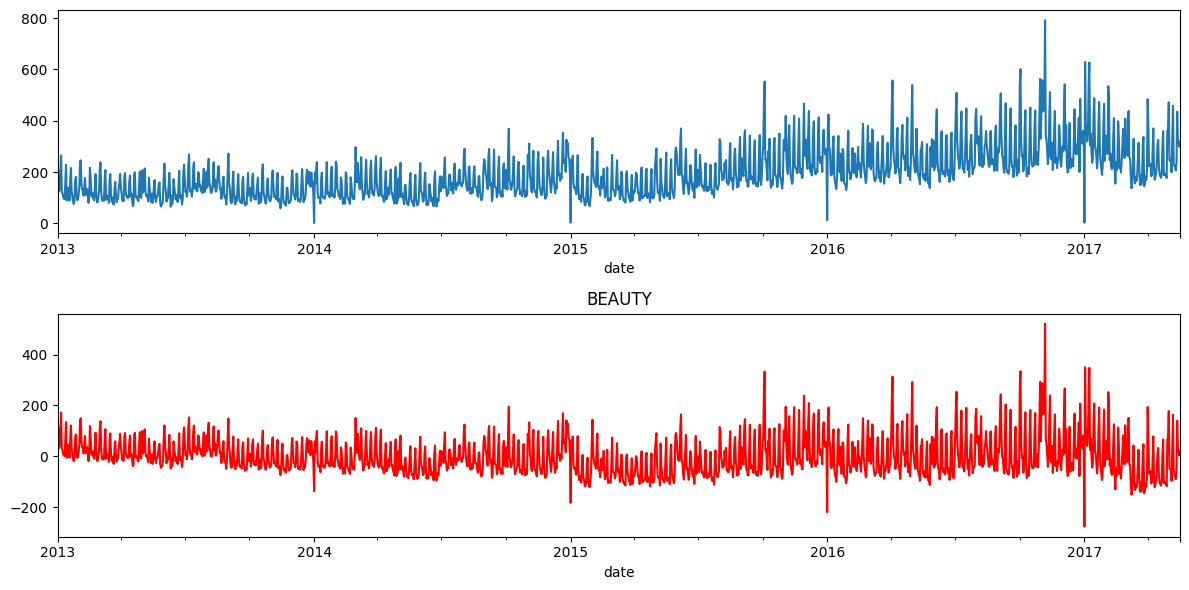

BEVERAGES


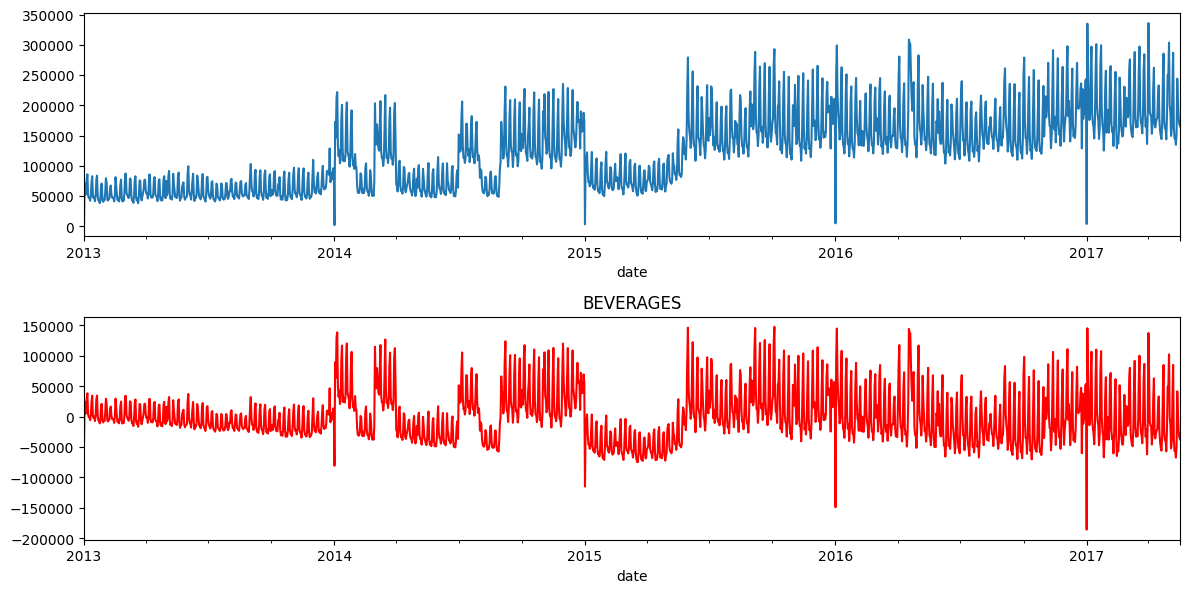

BOOKS


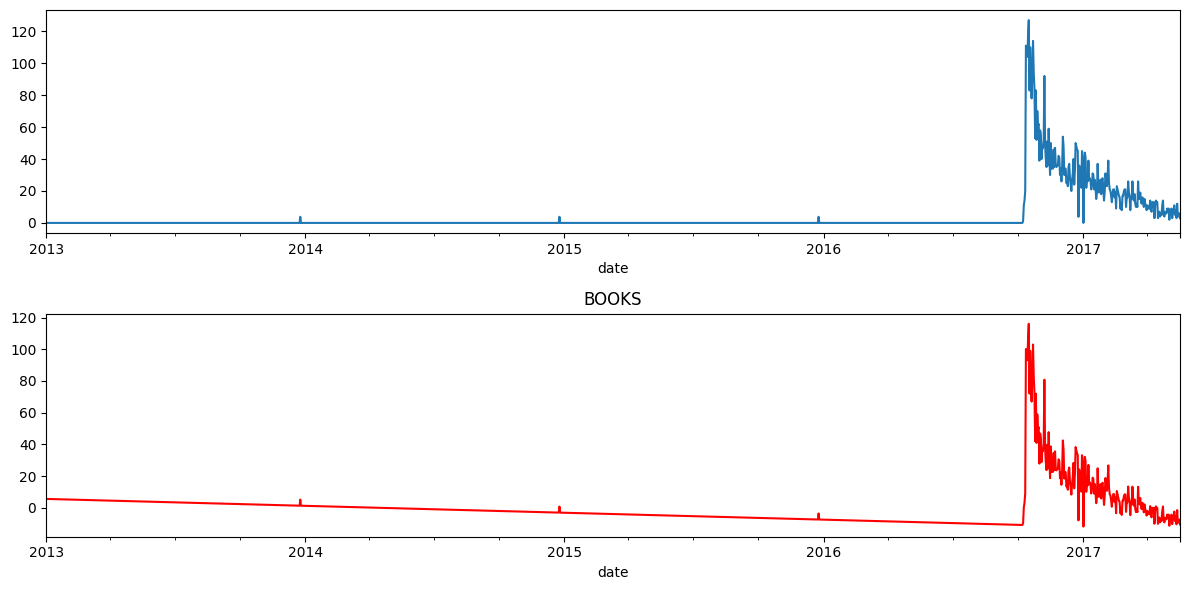

In [26]:
#Prueba para ver si se ha quitado la estacionalidad de los datos

dataframe_trend = models['AUTOMOTIVE'].predict(dataframes['AUTOMOTIVE'][0][['days_since_start']])

dataframe_without_trend = dataframes['AUTOMOTIVE'][0]['sales'] - dataframe_trend

NUM_FAMILIES = 5 #Variable que puedes cambiar para ver más o menos familias en el gráfico
for family, data in list(dataframes.items())[:NUM_FAMILIES]:
    print(family)
    dataframe_trend = models[family].predict(data[0][['days_since_start']])
    dataframe_without_trend = data[0]['sales'] - dataframe_trend
    fig = plt.figure(figsize=(12, 12))
    ax1 = fig.add_subplot(211)
    ax2 = fig.add_subplot(212)
    data[0]['sales'].plot(label='Train', figsize=(12, 6), ax=ax1)
    dataframe_without_trend.plot(label='Without Trend',color='red', figsize=(12, 6), ax=ax2)
    plt.title(family)
    plt.tight_layout()
    plt.show()
    